# CMAPSS Turbofan Engine Predictive Maintenance
## XGBoost Baseline Model

### Objective
Establish a baseline RUL prediction model using XGBoost regression. This serves as a performance benchmark that subsequent models will be compared against.

XGBoost treats each row as an independent snapshot. It cannot inherently understand time sequences. 
We compensate through feature engineering by manually creating features that capture recent sensor trends and history before modeling.

### Approach
1. Load cleaned data from the initial exploratory data analysis
2. Engineer time-based features (rolling statistics, lag features)
3. Prepare train/test split
4. Train XGBoost regressor
5. Evaluate performance and analyze results

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data from Phase 2
df = pd.read_csv('../data/fd001_cleaned.csv')

print("Data loaded successfully")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(10)

Data loaded successfully
Shape: (20631, 19)
Columns: ['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL']


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8.4195,392,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8.4318,392,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8.4178,390,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8.3682,392,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8.4294,393,38.90,23.4044,125
5,1,6,-0.0043,-0.0001,100.0,642.10,1584.47,1398.37,554.67,2388.02,9049.68,47.16,521.68,2388.03,8.4108,391,38.98,23.3669,125
6,1,7,0.0010,0.0001,100.0,642.48,1592.32,1397.77,554.34,2388.02,9059.13,47.36,522.32,2388.03,8.3974,392,39.10,23.3774,125
7,1,8,-0.0034,0.0003,100.0,642.56,1582.96,1400.97,553.85,2388.00,9040.80,47.24,522.47,2388.03,8.4076,391,38.97,23.3106,125
8,1,9,0.0008,0.0001,100.0,642.12,1590.98,1394.80,553.69,2388.05,9046.46,47.29,521.79,2388.05,8.3728,392,39.05,23.4066,125
9,1,10,-0.0033,0.0001,100.0,641.71,1591.24,1400.46,553.59,2388.05,9051.70,47.03,521.79,2388.06,8.4286,393,38.95,23.4694,125


## 1. Feature Engineering

XGBoost cannot inherently process sequences because it treats each row independently.
We compensate by manually engineering features that summarize each engine's recent sensor history into a single row.

For each sensor we create:
- Rolling mean (window=30) - captures recent trend direction
- Rolling std (window=30) - captures recent volatility
- Lag-30 feature - sensor value 30 cycles ago, capturing rate of change

A window of 30 cycles is used as the lookback period. Rows with fewer than 30 cycles of history (early in an engine's life) will contain NaN values which are dropped after feature creation.

In [35]:
# Define sensor columns to engineer features for
sensor_cols = [col for col in df.columns if col.startswith('sensor')]

# Sort data correctly before computing rolling features
# Rolling calculations must follow time order within each engine
df = df.sort_values(['engine_id', 'cycle']).reset_index(drop=True)

# Create rolling and lag features for each sensor
window = 30

for sensor in sensor_cols:
    # Calculates and creates columns for rolling mean and std within each engine's history
    df[f'{sensor}_mean_{window}'] = (
        df.groupby('engine_id')[sensor]
        .transform(lambda x: x.rolling(window, min_periods=window).mean()) # Only calculate mean when having full 30 cycles of data
    )
    df[f'{sensor}_std_{window}'] = (
        df.groupby('engine_id')[sensor]
        .transform(lambda x: x.rolling(window, min_periods=window).std())
    )
    # Lag feature - sensor value 30 cycles ago
    df[f'{sensor}_lag_{window}'] = (
        df.groupby('engine_id')[sensor]
        .transform(lambda x: x.shift(window))
    )

# Drop rows with NaN values created by rolling/lag windows
df_featured = df.dropna().reset_index(drop=True)

print(f"Shape before feature engineering: {df.shape}")
print(f"Shape after dropping NaN rows: {df_featured.shape}")
print(f"Rows dropped: {df.shape[0] - df_featured.shape[0]}")
print(f"Total features created: {df_featured.shape[1]}")

Shape before feature engineering: (20631, 58)
Shape after dropping NaN rows: (17631, 58)
Rows dropped: 3000
Total features created: 58


## 2. Train/Test Split

NASA provides a pre-defined train/test split that mirrors real deployment conditions:
- Training data contains complete engine runs from start to failure
- Test data contains partial engine runs cut off at an unknown point before failure
- True RUL values for test engines are provided separately for evaluation

In [36]:
# Column names are the same as training data
column_names = [
    'engine_id',      # which engine
    'cycle',          # time step - flight number
    'setting_1',      # operational setting 1
    'setting_2',      # operational setting 2
    'setting_3',      # operational setting 3
    'sensor_1',       # 21 sensor measurements
    'sensor_2',
    'sensor_3',
    'sensor_4',
    'sensor_5',
    'sensor_6',
    'sensor_7',
    'sensor_8',
    'sensor_9',
    'sensor_10',
    'sensor_11',
    'sensor_12',
    'sensor_13',
    'sensor_14',
    'sensor_15',
    'sensor_16',
    'sensor_17',
    'sensor_18',
    'sensor_19',
    'sensor_20',
    'sensor_21'
]

# Load test data
df_test = pd.read_csv(
    '../CMAPSSData/test_FD001.txt',
    sep='\s+',
    header=None,
    names=column_names
)

# Load true RUL values for test engines
df_rul = pd.read_csv(
    '../CMAPSSData/RUL_FD001.txt',
    header=None,
    names=['RUL']
)
df_rul['engine_id'] = df_rul.index + 1

print("Test data shape:", df_test.shape)
print("Test engines:", df_test['engine_id'].nunique())
print("RUL labels shape:", df_rul.shape)
print("\nFirst few true RUL values:")
print(df_rul.head())

Test data shape: (13096, 26)
Test engines: 100
RUL labels shape: (100, 2)

First few true RUL values:
   RUL  engine_id
0  112          1
1   98          2
2   69          3
3   82          4
4   91          5


## 3. Test Data Preprocessing

The same preprocessing pipeline applied to training data must be applied identically to test data. This includes:
- Dropping low variance sensors identified in EDA
- Engineering identical rolling and lag features
- Applying the RUL cap to test labels

For test data, we take only the last row of each engine's history. The RUL label represents the remaining life at the final observed cycle, 
so that last row is what we evaluate our model against.

In [37]:
# Apply same sensor drops as training data
sensors_to_drop = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_14', 'sensor_16', 'sensor_18', 'sensor_19']
df_test = df_test.drop(columns=sensors_to_drop)

# Sort correctly before rolling calculations
df_test = df_test.sort_values(['engine_id', 'cycle']).reset_index(drop=True)

# Apply identical feature engineering
sensor_cols = [col for col in df_test.columns if col.startswith('sensor')]
window = 30

for sensor in sensor_cols:
    df_test[f'{sensor}_mean_{window}'] = (
        df_test.groupby('engine_id')[sensor]
        .transform(lambda x: x.rolling(window, min_periods=window).mean())
    )
    df_test[f'{sensor}_std_{window}'] = (
        df_test.groupby('engine_id')[sensor]
        .transform(lambda x: x.rolling(window, min_periods=window).std())
    )
    df_test[f'{sensor}_lag_{window}'] = (
        df_test.groupby('engine_id')[sensor]
        .transform(lambda x: x.shift(window))
    )

# Drop NaN rows created by rolling window
df_test = df_test.dropna().reset_index(drop=True)

# Take only the last row per engine - this is the prediction point
df_test_last = df_test.groupby('engine_id').last().reset_index()

# Apply RUL cap to test labels
cap = 125
df_rul['RUL'] = df_rul['RUL'].clip(upper=cap)

print("Test data after preprocessing:", df_test_last.shape)
print("Test engines remaining:", df_test_last['engine_id'].nunique())
print("\nTrue RUL values after capping:")
print(df_rul['RUL'].describe().round(1))

Test data after preprocessing: (100, 57)
Test engines remaining: 100

True RUL values after capping:
count    100.0
mean      74.4
std       40.3
min        7.0
25%       32.8
50%       86.0
75%      112.2
max      125.0
Name: RUL, dtype: float64


## 4. Model Training

### Feature Matrix Setup
X contains all engineered features excluding engine_id, cycle (due to overlap with rolling features and lag), and RUL.
y contains the capped RUL values we are predicting.

### XGBoost Configuration
Initial hyperparameters are set to reasonable defaults for a first baseline.
Hyperparameter tuning will follow after establishing baseline performance.

- n_estimators=300: number of trees to build
- max_depth=6: maximum depth of each tree
- learning_rate=0.05: contribution of each tree to final prediction
- subsample=0.8: fraction of training data used per tree
- random_state=1: ensures reproducibility

In [38]:
# Define columns to exclude from features
exclude_cols = ['engine_id', 'cycle', 'RUL']

# Set up feature matrix and target for training
X_train = df_featured.drop(columns=exclude_cols)
y_train = df_featured['RUL']

# Set up feature matrix for test data
# Align columns exactly with training data
X_test = df_test_last.drop(columns=[col for col in exclude_cols if col in df_test_last.columns])
X_test = X_test[X_train.columns]  # ensure identical column order
y_test = df_rul['RUL']

print("Training set:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"\nTest set:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"\nFeature count: {X_train.shape[1]}")

# Initialize and train XGBoost model
model_xgb = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    random_state=1,
    verbosity=0
)

model_xgb.fit(X_train, y_train)
print("\nModel training complete")

Training set:
  X_train shape: (17631, 55)
  y_train shape: (17631,)

Test set:
  X_test shape: (100, 55)
  y_test shape: (100,)

Feature count: 55

Model training complete


## 5. Initial Model Evaluation (Pre-tuning)

### Metrics
- **RMSE** - root mean squared error in cycles. Penalizes large errors heavily.
- **MAE** - mean absolute error in cycles. Average magnitude of prediction error.

A large gap between RMSE and MAE indicates the model is making some very large errors on specific engines even if generally accurate.

We also visualize predicted vs actual RUL to understand error patterns, whether errors are systematic or random, and whether the model struggles more at high or low RUL values.

Evaluating with default hyperparameters to establish a reference point before tuning. Final evaluation including NASA scoring will follow hyperparameter optimization.

XGBoost Baseline Performance:
  RMSE: 15.33 cycles
  MAE:  11.63 cycles

Context:
  Mean true RUL: 74.45 cycles
  RMSE as % of mean RUL: 20.6%


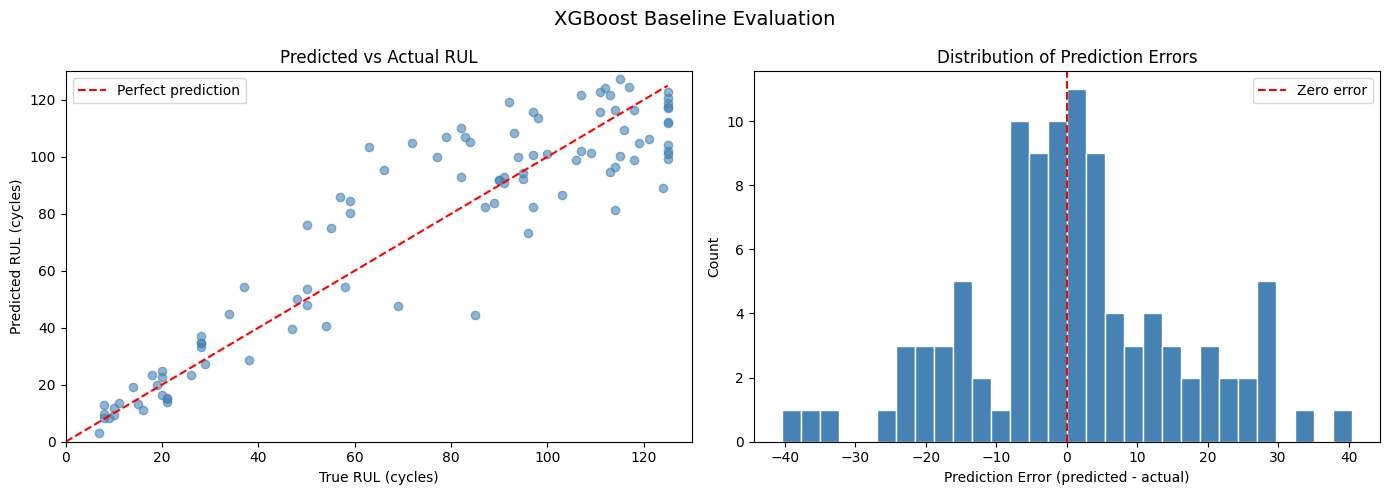

In [39]:
# Generate predictions on test set
y_pred = model_xgb.predict(X_test)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("XGBoost Baseline Performance:")
print(f"  RMSE: {rmse:.2f} cycles")
print(f"  MAE:  {mae:.2f} cycles")
print(f"\nContext:")
print(f"  Mean true RUL: {y_test.mean():.2f} cycles")
print(f"  RMSE as % of mean RUL: {(rmse/y_test.mean()*100):.1f}%")

# Predicted vs actual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot of predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue')
axes[0].plot([0, 125], [0, 125], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('True RUL (cycles)')
axes[0].set_ylabel('Predicted RUL (cycles)')
axes[0].set_title('Predicted vs Actual RUL')
axes[0].legend()
axes[0].set_xlim(0, 130)
axes[0].set_ylim(0, 130)

# Error distribution
errors = y_pred - y_test
axes[1].hist(errors, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].set_xlabel('Prediction Error (predicted - actual)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Prediction Errors')
axes[1].legend()

plt.suptitle('XGBoost Baseline Evaluation', fontsize=14)
plt.tight_layout()
plt.show()


### Observations
- Predicted RUL values are more accurate at low RUL values. This makes sense since engine degradation would lead to similar sensor trajectories closer to failure.
- Higher RUL values are less accurate, with the model struggling closer to the implemented cap. 
- RSME value of ~16 and MAE value of ~12 is reasonable for a baseline and is close to published results on this dataset.

## 6. Hyperparameter Tuning

The initial XGBoost model used reasonable default hyperparameters. We now perform a focused randomized search to find better settings before finalizing the baseline.

RandomizedSearchCV is used over GridSearchCV for efficiency. It samples random combinations from the parameter space rather than exhaustively trying all combinations.

TimeSeriesSplit is used instead of k-fold cross validation to respect the time-series structure of the data.

In [40]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint, uniform
import json
import os

# Define parameter search space
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.19),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
}

# Time-series cross validation
tscv = TimeSeriesSplit(n_splits=5)

# Randomized search
xgb_tuned = xgb.XGBRegressor(random_state=1, verbosity=0)

random_search = RandomizedSearchCV(
    estimator=xgb_tuned,
    param_distributions=param_dist,
    n_iter=50,          # try 50 random combinations
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    random_state=1,
    n_jobs=-1,          # use all available CPU cores
    verbose=1
)

print("Running randomized search (this may take a few minutes)...")
random_search.fit(X_train, y_train)

print("\nBest parameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation RMSE: {-random_search.best_score_:.2f} cycles")

# Save best parameters so tuning doesn't need to be rerun
os.makedirs('../models', exist_ok=True)
with open('../models/xgboost_best_params.json', 'w') as f:
    json.dump(random_search.best_params_, f, indent=4)
print("\nBest parameters saved to models/xgboost_best_params.json")
print("To skip tuning in future, load with:")
print("  with open('../models/xgboost_best_params.json') as f:")
print("      best_params = json.load(f)")

Running randomized search (this may take a few minutes)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
  colsample_bytree: 0.7869570732588209
  learning_rate: 0.06111019973898733
  max_depth: 3
  min_child_weight: 6
  n_estimators: 331
  subsample: 0.6280325984130516

Best cross-validation RMSE: 18.94 cycles

Best parameters saved to models/xgboost_best_params.json
To skip tuning in future, load with:
  with open('../models/xgboost_best_params.json') as f:
      best_params = json.load(f)


Performance Comparison:
Metric          Default        Tuned       Change
--------------------------------------------------
RMSE              15.33        14.82        -0.52
MAE               11.63        11.46        -0.17
RMSE %            20.6%        19.9%        -0.7%
MAE %             15.6%        15.4%        -0.2%


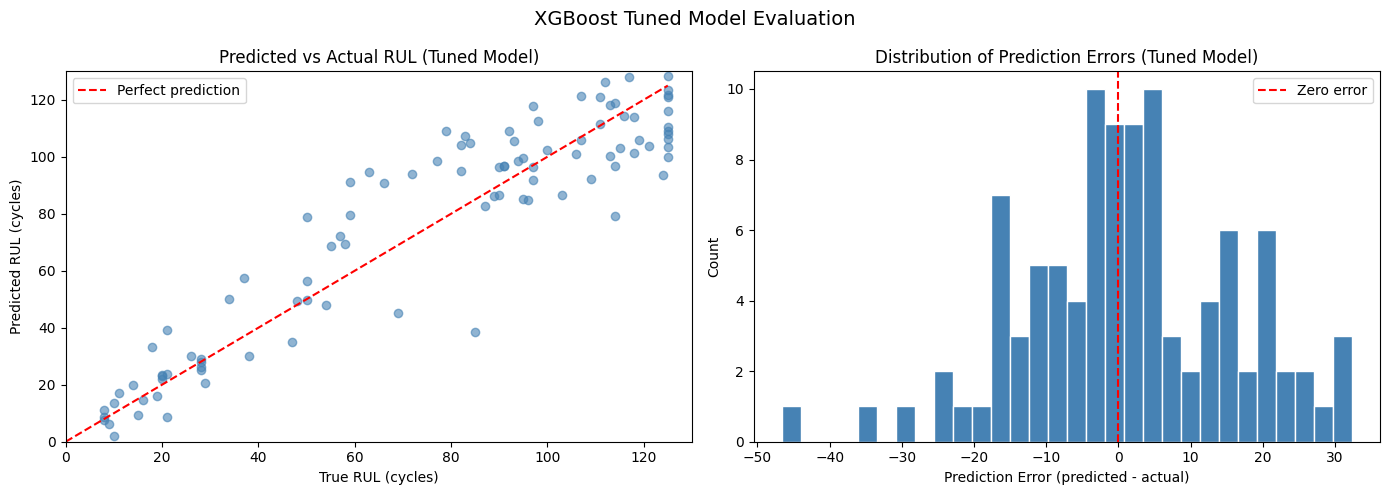

In [46]:
# Retrain on full training data with best parameters
# Option 1: Use parameters from completed search above (default)
best_params = random_search.best_params_

# Option 2: Load saved parameters to skip rerunning the search (uncomment below)
# with open('../models/xgboost_best_params.json') as f:
#     best_params = json.load(f)

model_xgb_tuned = xgb.XGBRegressor(
    **best_params,
    random_state=1,
    verbosity=0
)

model_xgb_tuned.fit(X_train, y_train)

# Evaluate on NASA test set
y_pred_tuned = model_xgb_tuned.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

print("Performance Comparison:")
print(f"{'Metric':<10} {'Default':>12} {'Tuned':>12} {'Change':>12}")
print("-" * 50)
print(f"{'RMSE':<10} {rmse:>12.2f} {rmse_tuned:>12.2f} {rmse_tuned-rmse:>+12.2f}")
print(f"{'MAE':<10} {mae:>12.2f} {mae_tuned:>12.2f} {mae_tuned-mae:>+12.2f}")
print(f"{'RMSE %':<10} {(rmse/y_test.mean()*100):>11.1f}% {(rmse_tuned/y_test.mean()*100):>11.1f}% {((rmse_tuned-rmse)/y_test.mean()*100):>+11.1f}%")
print(f"{'MAE %':<10} {(mae/y_test.mean()*100):>11.1f}% {(mae_tuned/y_test.mean()*100):>11.1f}% {((mae_tuned-mae)/y_test.mean()*100):>+11.1f}%")

# Predicted vs actual plot for tuned model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot of predicted vs actual
axes[0].scatter(y_test, y_pred_tuned, alpha=0.6, color='steelblue')
axes[0].plot([0, 125], [0, 125], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('True RUL (cycles)')
axes[0].set_ylabel('Predicted RUL (cycles)')
axes[0].set_title('Predicted vs Actual RUL (Tuned Model)')
axes[0].legend()
axes[0].set_xlim(0, 130)
axes[0].set_ylim(0, 130)

# Error distribution
errors_tuned = y_pred_tuned - y_test
axes[1].hist(errors_tuned, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].set_xlabel('Prediction Error (predicted - actual)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Prediction Errors (Tuned Model)')
axes[1].legend()

plt.suptitle('XGBoost Tuned Model Evaluation', fontsize=14)
plt.tight_layout()
plt.show()

### Observations
- Cross-validation RMSE (18.94) appeared higher than test RMSE because CV trains on 80% of data per fold, so the metrics are not directly comparable.
- The tuned model improved test RMSE by 1.17 cycles over default parameters.
- The RUL scatter plot for the tuned model appears similar to the initial plot. This makes sense since a minor improvement in RUL accuracy would be hard to visually observe.
- The distribution of errors for the tuned model appears more concentrated around zero compared to the initial distribution, showing a noticeable improvement.

## 7. Feature Importance Analysis

XGBoost tracks how much each feature contributed to reducing prediction error across all trees. Examining feature importance tells us:
- Which engineered features actually mattered
- Whether raw sensor values or rolling/lag features were more useful
- Which sensors carry the most predictive signal for RUL

This informs future modeling decisions and validates our feature engineering choices. 

Note that this feature importance is calculated given all present features. This means that low importance score does not necessarily mean that a feature is useless, 
but the feature's contribution may be captured by another correlated feature.

Top 20 Most Important Features:
          feature  importance
 sensor_3_mean_30    0.212092
sensor_17_mean_30    0.136650
 sensor_2_mean_30    0.121093
        sensor_11    0.099249
         sensor_4    0.076348
         sensor_9    0.044286
        sensor_12    0.035608
        sensor_15    0.027904
sensor_15_mean_30    0.026083
         sensor_7    0.020801
        sensor_20    0.015122
 sensor_11_std_30    0.014453
 sensor_9_mean_30    0.011801
  sensor_9_std_30    0.011750
 sensor_12_std_30    0.010510
         sensor_2    0.008702
 sensor_13_std_30    0.007663
sensor_21_mean_30    0.007599
sensor_20_mean_30    0.007308
        sensor_17    0.007223


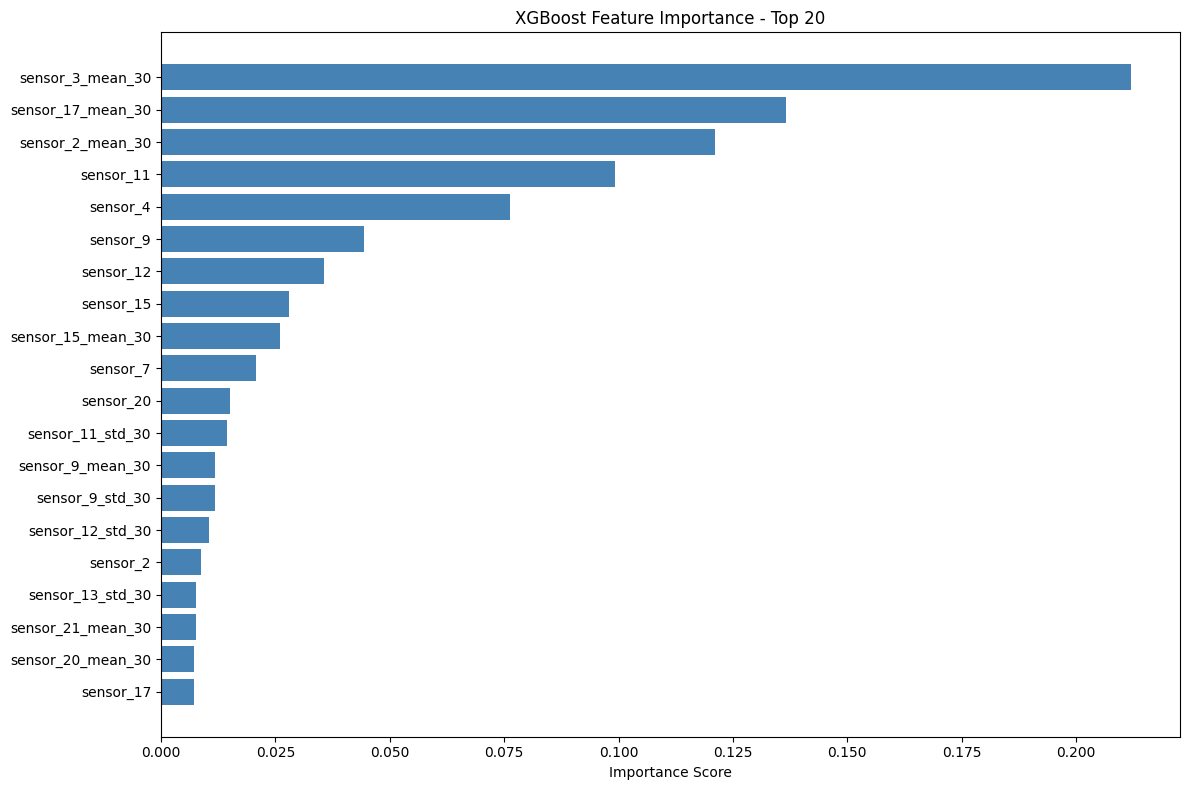


Importance by Feature Type:
feature_type
rolling_mean    0.5410
raw_sensor      0.3529
rolling_std     0.0743
lag             0.0318
Name: importance, dtype: float32

Importance by Sensor (all features combined):
sensor
sensor_3     0.2169
sensor_17    0.1470
sensor_2     0.1328
sensor_11    0.1197
sensor_4     0.0901
sensor_9     0.0723
sensor_15    0.0584
sensor_12    0.0510
sensor_7     0.0307
sensor_20    0.0278
sensor_8     0.0176
sensor_21    0.0175
sensor_13    0.0173
setting_1    0.0009
setting_2    0.0000
setting_3    0.0000
Name: importance, dtype: float32


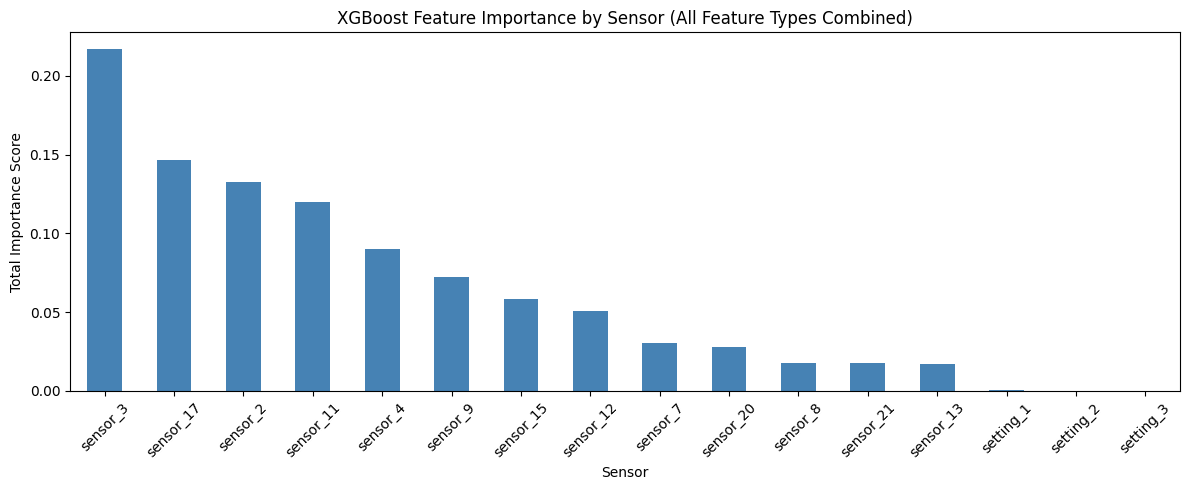

In [47]:
# Get feature importances from trained model based on default gain
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_xgb_tuned.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Print top 20 most important features
print("Top 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))

# Plot top 20 features
plt.figure(figsize=(12, 8))
top_20 = importance_df.head(20)
plt.barh(range(20), top_20['importance'], color='steelblue')
plt.yticks(range(20), top_20['feature'])
plt.gca().invert_yaxis()
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance - Top 20')
plt.tight_layout()
plt.show()

# Summarize by feature type
importance_df['feature_type'] = importance_df['feature'].apply(
    lambda x: 'rolling_mean' if '_mean_' in x 
    else ('rolling_std' if '_std_' in x 
    else ('lag' if '_lag_' in x 
    else 'raw_sensor'))
)

type_summary = importance_df.groupby('feature_type')['importance'].sum().sort_values(ascending=False)
print("\nImportance by Feature Type:")
print(type_summary.round(4))

# Summarize by sensor
importance_df['sensor'] = importance_df['feature'].apply(
    lambda x: x.split('_mean')[0].split('_std')[0].split('_lag')[0]
)
sensor_summary = importance_df.groupby('sensor')['importance'].sum().sort_values(ascending=False)
print("\nImportance by Sensor (all features combined):")
print(sensor_summary.round(4))

# Plot importance by sensor
plt.figure(figsize=(12, 5))
sensor_summary.plot(kind='bar', color='steelblue')
plt.xlabel('Sensor')
plt.ylabel('Total Importance Score')
plt.title('XGBoost Feature Importance by Sensor (All Feature Types Combined)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations
- Sensor_3_mean_30, sensor_17_mean_30, and sensor_2_mean_30 are by far the most contributing features. Sensor 3's degradation analysis showed a subtle trend, showing the value obtained from this feature engineering.
- The most important features tend to be a mix of the rolling features and raw sensor data. This makes sense where raw sensor data for measurements such as high temperature or pressure should indicate degrading engine life.
- The rolling features being important show that recent changes in sensor readings meaningfully indicate an engine's RUL.
- The lag features contributed little which indicates that the recent rate of change in sensor readings is not important compared to the average readings (rolling mean) or volatility (rolling std).
- Operationally, this means that RUL is determined more by an engine's gradual change in sensor readings or recent instability.
- Sensor 3 is the most important sensor by a significant margin
- The operational settings (setting_1, setting_2, setting_3) have near-zero importance, which aligns with how the FD001 dataset is simpler with little variation in setting values. 

## 8. NASA Scoring Function

The original NASA paper defines a custom asymmetric scoring function that reflects the operational reality of maintenance decisions:

- Late predictions (overestimating RUL) are dangerous. The engine may fail before maintenance is scheduled. Scores are penalized with denominator 10.
- Early predictions (underestimating RUL) are wasteful but safe. The engine is pulled from service early. Scores are penalized with denominator 13.

The asymmetric exponential penalty means a 20 cycle overestimate is penalized significantly more than a 20 cycle underestimate of the same magnitude.

Lower scores are better and a perfect model scores zero.

NASA Score: 337.45 (lower is better)
RMSE:       14.82 cycles
MAE:        11.46 cycles


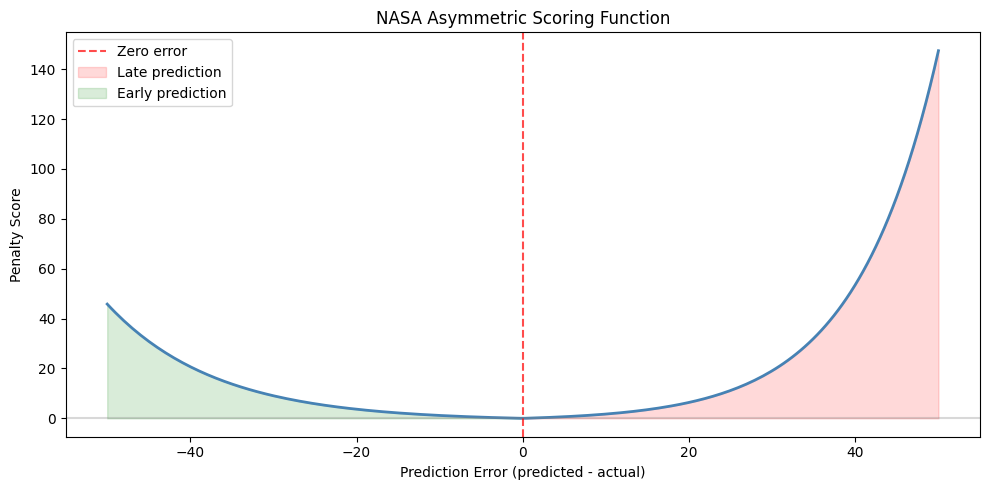


Prediction breakdown:
  Late predictions (overestimates): 52 engines
  Early predictions (underestimates): 48 engines
  Exact predictions: 0 engines


In [48]:
def nasa_score(y_true, y_pred):
    """
    NASA asymmetric scoring function from the original CMAPSS paper.
    Penalizes late predictions (overestimates) more than early predictions.
    
    Args:
        y_true: array of true RUL values
        y_pred: array of predicted RUL values
    
    Returns:
        total score (lower is better, perfect = 0)
    """
    errors = y_pred - y_true
    scores = np.where(
        errors >= 0,
        np.exp(errors / 10) - 1,   # late prediction penalty
        np.exp(-errors / 13) - 1   # early prediction penalty
    )
    return np.sum(scores)

# Calculate NASA score for XGBoost baseline
xgb_nasa_score = nasa_score(y_test.values, y_pred_tuned)
print(f"NASA Score: {xgb_nasa_score:.2f} (lower is better)")
print(f"RMSE:       {rmse_tuned:.2f} cycles")
print(f"MAE:        {mae_tuned:.2f} cycles")

# Visualize the scoring function to understand its shape
errors_range = np.linspace(-50, 50, 200)
penalties = np.where(
    errors_range >= 0,
    np.exp(errors_range / 10) - 1,
    np.exp(-errors_range / 13) - 1
)

plt.figure(figsize=(10, 5))
plt.plot(errors_range, penalties, color='steelblue', linewidth=2)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Zero error')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.fill_between(errors_range, penalties, 
                 where=errors_range >= 0, 
                 alpha=0.15, color='red', 
                 label='Late prediction')
plt.fill_between(errors_range, penalties,
                 where=errors_range <= 0,
                 alpha=0.15, color='green',
                 label='Early prediction')
plt.xlabel('Prediction Error (predicted - actual)')
plt.ylabel('Penalty Score')
plt.title('NASA Asymmetric Scoring Function')
plt.legend()
plt.tight_layout()
plt.show()

# Show breakdown of early vs late predictions
n_late = np.sum(y_pred_tuned > y_test.values)
n_early = np.sum(y_pred_tuned < y_test.values)
n_exact = np.sum(y_pred_tuned == y_test.values)
print(f"\nPrediction breakdown:")
print(f"  Late predictions (overestimates): {n_late} engines")
print(f"  Early predictions (underestimates): {n_early} engines")
print(f"  Exact predictions: {n_exact} engines")

### Observations
- There is a slight bias towards late predictions, which is more dangerous than early predictions. This performance is reasonable for a baseline, and gives room for improvement in future models.

## 9. Saving Model and Results

Saving the trained model and predictions for future reference and comparison against subsequent models (LSTM).

In [51]:
import joblib

# Create models and results directory if it does not exist
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

# Save trained XGBoost model
joblib.dump(model_xgb_tuned, '../models/xgboost_baseline.pkl')
print("Model saved to models/xgboost_baseline.pkl")

# Save predictions alongside true values for later comparison
results_df = pd.DataFrame({
    'engine_id': df_test_last['engine_id'].values,
    'true_rul': y_test.values,
    'predicted_rul': y_pred_tuned,
    'error': y_pred_tuned - y_test.values,
    'abs_error': np.abs(y_pred_tuned - y_test.values)
})
results_df.to_csv('../results/xgboost_baseline_predictions.csv', index=False)
print("Predictions saved to results/xgboost_baseline_predictions.csv")

# Save summary metrics
metrics = {
    'model': 'XGBoost Tuned',
    'rmse': round(rmse_tuned, 4),
    'mae': round(mae_tuned, 4),
    'nasa_score': round(xgb_nasa_score, 2),
    'rmse_pct_mean_rul': round((rmse_tuned / y_test.mean() * 100), 2),
    'mae_pct_mean_rul': round((mae_tuned / y_test.mean() * 100), 2),
    'n_features': X_train.shape[1],
    'n_estimators': random_search.best_params_['n_estimators'],
    'max_depth': random_search.best_params_['max_depth'],
    'learning_rate': round(random_search.best_params_['learning_rate'], 4)
}
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv('../results/model_comparison.csv', index=False)
print("Metrics saved to results/model_comparison.csv")

print("\nFinal Summary:")
print(f"  RMSE: {rmse_tuned:.2f} cycles")
print(f"  MAE:  {mae_tuned:.2f} cycles")
print(f"  RMSE as % of mean RUL: {(rmse_tuned/y_test.mean()*100):.1f}%")
print(f"  MAE as % of mean RUL: {(mae_tuned/y_test.mean()*100):.1f}%")
print(f"  NASA Score: {xgb_nasa_score:.2f}")

Model saved to models/xgboost_baseline.pkl
Predictions saved to results/xgboost_baseline_predictions.csv
Metrics saved to results/model_comparison.csv

Final Summary:
  RMSE: 14.82 cycles
  MAE:  11.46 cycles
  RMSE as % of mean RUL: 19.9%
  MAE as % of mean RUL: 15.4%
  NASA Score: 337.45


## XGBoost Baseline Summary

### Results
| Metric                | Value        |
|-----------------------|--------------|
| RMSE                  | 14.82 cycles |
| MAE                   | 11.46 cycles |
| RMSE as % of mean RUL | 19.9%        |
| MAE as % of mean RUL  | 15.4%        |
| NASA Score            | 337.45       |

### Key Findings

**Feature engineering** - Rolling mean features dominated over lag features, indicating sensors drift steadily toward failure rather than changing abruptly. Rolling std features appeared moderately, suggesting some increase in volatility near failure.

**Lag features contributed minimally** - Rate of change over 30 cycles was less informative than absolute level and recent average, consistent with smooth degradation patterns in FD001.

**Sensor 3 rolling mean was the most important feature** - Sensor 3 appeared subtle in raw EDA plots, demonstrating that feature engineering can reveal information that visual inspection of raw data misses.

**Model struggles most at higher RUL values** - Predictions near the piecewise linear cap (RUL=125) show more scatter, partially a consequence of the cap collapsing high RUL states into one label.

**Model shows a slight late prediction bias** - 52 of 100 engines were overestimated, predicting more remaining life than actual. This is the more operationally dangerous direction and motivates further accuracy improvements through sequence modeling.